In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import QDRANT_URL, QDRANT_API_KEY, OPENAI_API_KEY, OPENAI_MODEL, OPENAI_API_URL,\
     DENSE_EMBEDDING_MODEL_PATH, OPENAI_MODEL_MINI, INTERIM_DATA_DIR, PROCESSED_DATA_DIR, DEVICE, \
     DEEPSEEK_MODEL, QWEN_37_PLUS, GEMMA_4_31B, GEMINI_31_FLASH_LITE

from src.generation_metrics import (
    run_generation_evaluation_pipeline,
    compute_generation_metrics,
    combine_generation_metrics,
)
from src.plots import plot_combined_generation_metrics

/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = os.path.join(PROCESSED_DATA_DIR, "sakila", "sakila_inline_short.sqlite.db")
DATABASE_NAME = "sakila"


sqlite_config = {
    "params": {
        "url": str(url) 
    },
    "type": "sqlite"}

qdrant_config = {"fastembed_model": DENSE_EMBEDDING_MODEL_PATH,
                 "url": QDRANT_URL, 
                 "api_key": QDRANT_API_KEY,
                 "device": DEVICE}

openai_config = {"api_key": OPENAI_API_KEY,
                 "model": OPENAI_MODEL,
                 "base_url": OPENAI_API_URL,
                 "temperature": 0.01}

In [3]:
rewritten_descriptions_csv_path = os.path.join(INTERIM_DATA_DIR, DATABASE_NAME, "query_descriptions", "query_descriptions_inline_short_rewritten.csv")

### Check generation quality using the same SQL-description that was used to generate ground truth SQL-scripts

In [ ]:

predicted_dirs = run_generation_evaluation_pipeline(
    descriptions_csv_path=rewritten_descriptions_csv_path,
    interim_dir=INTERIM_DATA_DIR,
    database_name=DATABASE_NAME,
    models={
        # "gpt-5-4-nano": OPENAI_MODEL_MINI,
        "gemini-3-1-flash-lite": GEMINI_31_FLASH_LITE
    },
    qdrant_config=qdrant_config,
    openai_config=openai_config,
    comment_styles=("yaml", "inline"),
    description_styles=("technical", "short", "business"),
    db_config=sqlite_config,
    n_folds=5,
    source_column="query",
)

print("Predicted result dirs:", predicted_dirs)

In [6]:
ground_truth_results_dir = INTERIM_DATA_DIR / DATABASE_NAME / "results"

generation_metrics_paths_source_column_query = compute_generation_metrics(
    ground_truth_results_dir=ground_truth_results_dir,
    predicted_results_dirs=predicted_dirs,
    descriptions_csv_path=rewritten_descriptions_csv_path,
)

for path in generation_metrics_paths_source_column_query:
    print(path.name)
    df = pd.read_csv(path)
    display(df.groupby("difficulty")['label'].value_counts())

inline_business_gemini-3-1-flash-lite_query.csv


difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not matching number of rows and cols    12
            Not generated                            5
            Not matching number of columns           2
            Not matching number of rows              2
            Not matching values                      1
medium      Not matching values                     17
            Everything matches                      10
            Not matching number of columns           7
            Not generated                            3
            Not matching number of rows              2
Name: count, dtype: int64

inline_business_gpt-5-4-nano_query.csv


difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not generated                           13
            Not matching number of rows and cols     6
            Not matching number of columns           2
            Not matching number of rows              1
medium      Not matching values                     18
            Not matching number of columns           7
            Everything matches                       6
            Not generated                            5
            Not matching number of rows              2
            Not matching number of rows and cols     1
Name: count, dtype: int64

inline_short_gemini-3-1-flash-lite_query.csv


...

difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not generated                           15
            Not matching number of rows and cols     4
            Not matching number of rows              3
medium      Not matching values                     17
            Everything matches                      10
            Not matching number of columns           6
            Not generated                            4
            Not matching number of rows              1
            Not matching number of rows and cols     1
Name: count, dtype: int64

yaml_technical_gemini-3-1-flash-lite_query.csv


difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not matching number of rows and cols    12
            Not generated                            6
            Not matching number of columns           2
            Not matching number of rows              1
            Not matching values                      1
medium      Not matching values                     18
            Everything matches                      12
            Not matching number of columns           6
            Not matching number of rows              2
            Not generated                            1
Name: count, dtype: int64

yaml_technical_gpt-5-4-nano_query.csv


difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not generated                           11
            Not matching number of rows and cols     7
            Not matching number of rows              2
            Not matching number of columns           1
            Not matching values                      1
medium      Not matching values                     19
            Not matching number of columns           8
            Everything matches                       6
            Not generated                            3
            Not matching number of rows              2
            Not matching number of rows and cols     1
Name: count, dtype: int64

In [7]:
combined_query_path = combine_generation_metrics(
    generation_metrics_paths=generation_metrics_paths_source_column_query,
    database_name=DATABASE_NAME,
    source_column="query",
)
plot_saved_paths = plot_combined_generation_metrics(
    combined_query_path,
    style_filters=[("inline", "short"), ("inline", "business"), ("inline", "technical"),
                   ("yaml", "short"), ("yaml", "business"), ("yaml", "technical")],
)
print("Combined query metrics:", combined_query_path)
display(pd.read_excel(combined_query_path, index_col=[0, 1, 2, 3]))


Combined query metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_generation_query.xlsx


Everything matches  \
difficulty model_name            comment_style description_style                       
easy       gemini-3-1-flash-lite inline        business                           38   
                                               short                              38   
                                               technical                          38   
                                 yaml          business                           38   
                                               short                              38   
                                               technical                          38   
           gpt-5-4-nano          inline        business                           38   
                                               short                              38   
                                               technical                          38   
                                 yaml          business                           38   
                                               short                              38   
                                               technical                          38   
medium     gemini-3-1-flash-lite inline        business                           10   
                                               short                               9   
                                               technical                          12   
                                 yaml          business                           11   
                                               short                              11   
                                               technical                          12   
           gpt-5-4-nano          inline        business                            6   
                                               short                               9   
                                               technical                           9   
                                 yaml          business                            8   
                                               short                              10   
                                               technical                           6   
hard       gemini-3-1-flash-lite inline        business                            0   
                                               short                               0   
                                               technical                           0   
                                 yaml          business                            0   
                                               short                               0   
                                               technical                           0   
           gpt-5-4-nano          inline        business                            0   
                                               short                               0   
                                               technical                           0   
                                 yaml          business                            0   
                                               short                               0   
                                               technical                           0   

                                                                  Not matching values  \
difficulty model_name            comment_style description_style                        
easy       gemini-3-1-flash-lite inline        business                             0   
                                               short                                0   
                                               technical                            0   
                                 yaml          business                             0   
                                               short                                0   
                                               technical                            0   
         

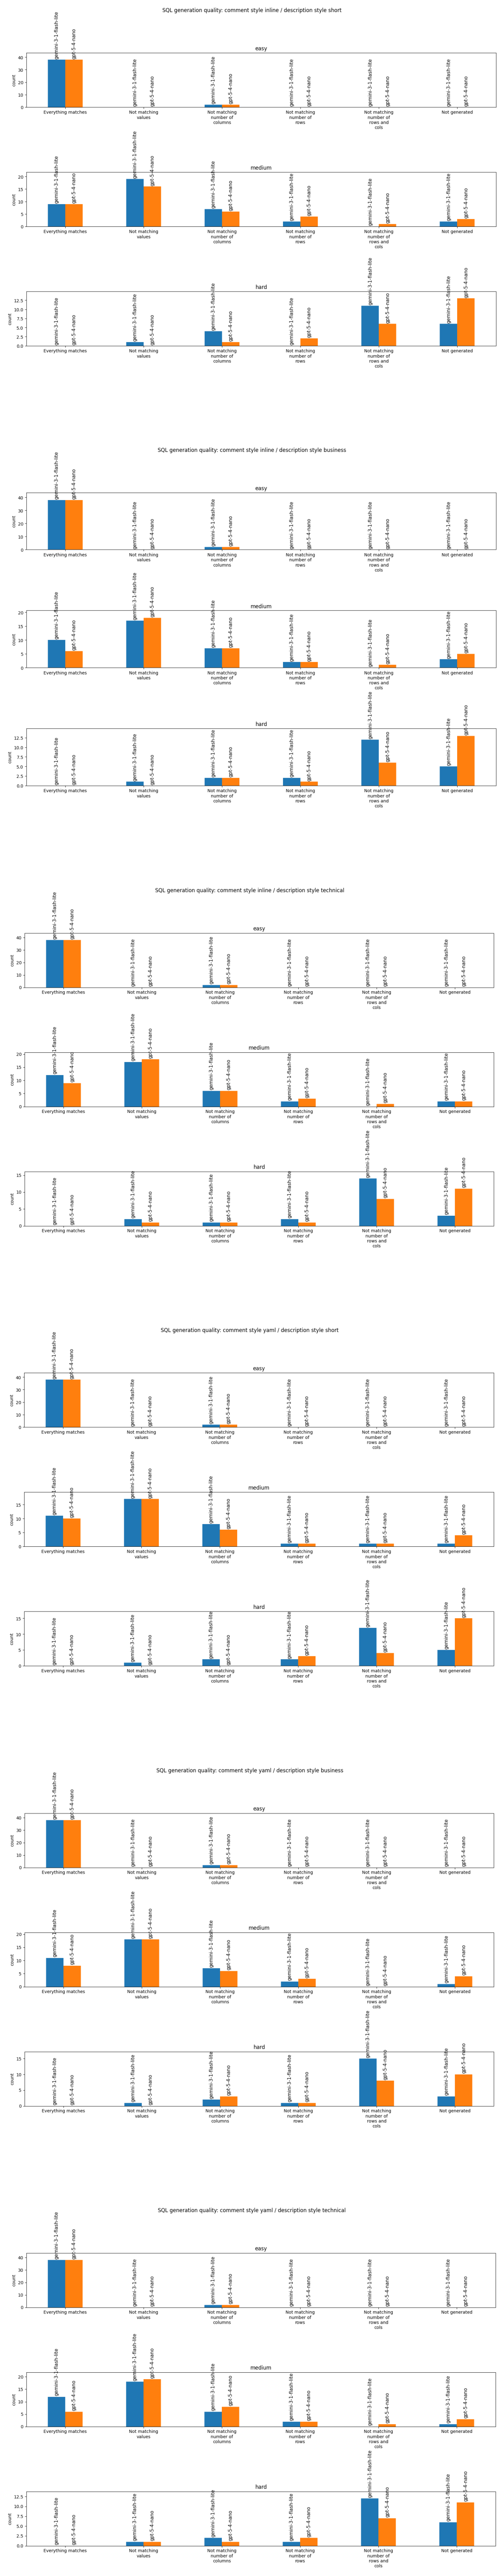

In [8]:
fig = plt.figure(figsize=(20, 12 * len(plot_saved_paths)))
for index, plot_path in enumerate(plot_saved_paths):
    img = mpimg.imread(plot_path)
    fig.add_subplot(len(plot_saved_paths), 1, index + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

### Check generation quality using rewritten query descriptions in different styles, instead of using original query description used for generating ground truth SQL-scripts

In [ ]:

predicted_dirs = run_generation_evaluation_pipeline(
    descriptions_csv_path=rewritten_descriptions_csv_path,
    interim_dir=INTERIM_DATA_DIR,
    database_name=DATABASE_NAME,
    models={
        "gpt-5-4-nano": OPENAI_MODEL_MINI,
        "gemini-3-1-flash-lite": GEMINI_31_FLASH_LITE
    },
    qdrant_config=qdrant_config,
    openai_config=openai_config,
    comment_styles=("yaml", "inline"),
    description_styles=("technical", "short", "business"),
    db_config=sqlite_config,
    n_folds=5,
)

print("Predicted result dirs:", predicted_dirs)

In [5]:
ground_truth_results_dir = INTERIM_DATA_DIR / DATABASE_NAME / "results"

generation_metrics_paths = compute_generation_metrics(
    ground_truth_results_dir=ground_truth_results_dir,
    predicted_results_dirs=predicted_dirs,
    descriptions_csv_path=rewritten_descriptions_csv_path,
)

for path in generation_metrics_paths:
    print(path.name)
    df = pd.read_csv(path)
    display(df.groupby("difficulty")['label'].value_counts())

yaml_technical_gpt-5-4-nano.csv


difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not generated                           17
            Not matching number of rows and cols     5
medium      Not matching values                     13
            Not matching number of columns           9
            Not generated                            8
            Everything matches                       4
            Not matching number of rows              3
            Not matching number of rows and cols     2
Name: count, dtype: int64

yaml_short_gpt-5-4-nano.csv


difficulty  label                               
easy        Everything matches                      31
            Not matching number of columns           9
hard        Not matching number of rows and cols    11
            Not generated                            9
            Not matching number of rows              2
medium      Not matching number of columns          14
            Not matching values                     13
            Everything matches                       4
            Not matching number of rows              4
            Not generated                            2
            Not matching number of rows and cols     2
Name: count, dtype: int64

yaml_business_gpt-5-4-nano.csv


...

difficulty  label                               
easy        Everything matches                      38
            Not matching number of columns           2
hard        Not matching number of rows and cols    16
            Not generated                            5
            Not matching number of rows              1
medium      Not matching values                     18
            Everything matches                       7
            Not generated                            6
            Not matching number of columns           5
            Not matching number of rows and cols     2
            Not matching number of rows              1
Name: count, dtype: int64

inline_short_gemini-3-1-flash-lite.csv


difficulty  label                               
easy        Everything matches                      29
            Not matching number of columns          11
hard        Not matching number of rows and cols    11
            Not generated                            6
            Not matching number of columns           3
            Not matching number of rows              2
medium      Not matching number of columns          15
            Not matching values                     12
            Everything matches                       5
            Not matching number of rows              4
            Not generated                            2
            Not matching number of rows and cols     1
Name: count, dtype: int64

inline_business_gemini-3-1-flash-lite.csv


difficulty  label                               
easy        Everything matches                      20
            Not matching number of rows             17
            Not matching number of columns           3
hard        Not matching number of rows and cols    15
            Not generated                            4
            Not matching number of columns           2
            Not matching number of rows              1
medium      Not matching values                     13
            Not matching number of columns          11
            Everything matches                       8
            Not matching number of rows              4
            Not generated                            2
            Not matching number of rows and cols     1
Name: count, dtype: int64

In [9]:
combined_rewritten_path = combine_generation_metrics(
    generation_metrics_paths=generation_metrics_paths,
    database_name=DATABASE_NAME,
    source_column=None,
)
plot_saved_rewritten_paths = plot_combined_generation_metrics(
    combined_rewritten_path,
    style_filters=[("inline", "short"), ("inline", "business"), ("inline", "technical"),
                   ("yaml", "short"), ("yaml", "business"), ("yaml", "technical")],
)
print("Combined rewritten metrics:", combined_rewritten_path)
display(pd.read_excel(combined_rewritten_path, index_col=[0, 1, 2, 3]))

Combined rewritten metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_generation_rewritten.xlsx


Everything matches  \
difficulty model_name            comment_style description_style                       
easy       gemini-3-1-flash-lite inline        business                           20   
                                               short                              29   
                                               technical                          38   
                                 yaml          business                           20   
                                               short                              29   
                                               technical                          38   
           gpt-5-4-nano          inline        business                           23   
                                               short                              30   
                                               technical                          39   
                                 yaml          business                           31   
                                               short                              31   
                                               technical                          38   
medium     gemini-3-1-flash-lite inline        business                            8   
                                               short                               5   
                                               technical                           7   
                                 yaml          business                            8   
                                               short                               6   
                                               technical                           7   
           gpt-5-4-nano          inline        business                            7   
                                               short                               4   
                                               technical                           4   
                                 yaml          business                            8   
                                               short                               4   
                                               technical                           4   
hard       gemini-3-1-flash-lite inline        business                            0   
                                               short                               0   
                                               technical                           0   
                                 yaml          business                            0   
                                               short                               0   
                                               technical                           0   
           gpt-5-4-nano          inline        business                            0   
                                               short                               0   
                                               technical                           0   
                                 yaml          business                            0   
                                               short                               0   
                                               technical                           0   

                                                                  Not matching values  \
difficulty model_name            comment_style description_style                        
easy       gemini-3-1-flash-lite inline        business                             0   
                                               short                                0   
                                               technical                            0   
                                 yaml          business                             0   
                                               short                                0   
                                               technical                            0   
         

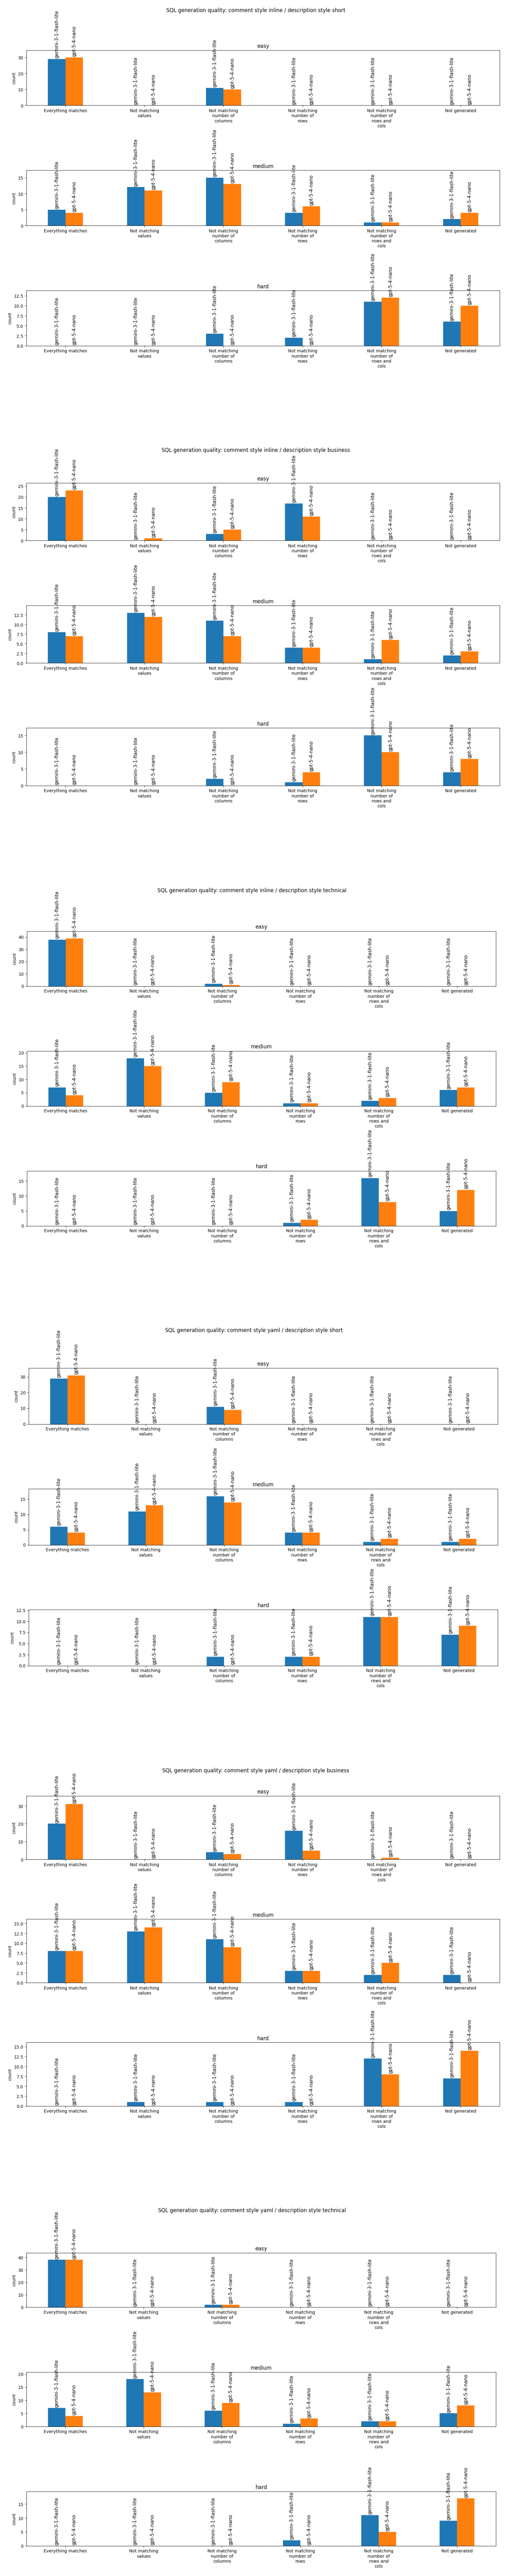

In [7]:
fig = plt.figure(figsize=(20, 12 * len(plot_saved_rewritten_paths)))
for index, plot_path in enumerate(plot_saved_rewritten_paths):
    img = mpimg.imread(plot_path)
    fig.add_subplot(len(plot_saved_rewritten_paths), 1, index + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()